# Google Playstore Case Study

In this module you’ll be learning data visualisation with the help of a case study. This will enable you to understand how visualisation aids you in solving business problems. 

**Problem Statement**

The team at Google Play Store wants to develop a feature that would enable them to boost visibility for the most promising apps. Now, this analysis would require a preliminary understanding of the features that define a well-performing app. You can ask questions like:
- Does a higher size or price necessarily mean that an app would perform better than the other apps? 
- Or does a higher number of installs give a clear picture of which app would have a better rating than others?




### Session 1 - Introduction to Data Visualisation

In [5]:
#import the libraries
import numpy as np
import pandas as pd

In [6]:
#read the dataset 
inp0 = pd.read_csv(r'C:\Users\krato\Downloads\Python\googleplaystore_v2.csv')
inp0.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
#Check the shape
inp0.shape

(10841, 13)

### Data Handling and Cleaning

The first few steps involve making sure that there are no __missing values__ or __incorrect data types__ before we proceed to the analysis stage.

 - For Missing Values fix
    - Dropping the rows containing the missing values
    - Imputing missing values

 
 - Incorrect Data Types fix
   
    - Clean certain values 
    - Clean and convert column if needed
 

In [10]:
#Check the datatypes of all the columns of the dataframe
inp0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  float64
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.1+ MB


#### Missing Value Treatment

In [12]:
#Check the number of null values in the columns
inp0.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Handling missing values for rating
 - Ratings is the target variable
 - drop the records

In [14]:
#Drop the rows having null values in the Rating field
inp1= inp0[~inp0.Rating.isnull()]

#Check the shape of the dataframe
inp1.shape

(9367, 13)

In [16]:
#Check the number of nulls in the dataframe again and find the total number of null values

inp1.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       4
Android Ver       3
dtype: int64

In [17]:
#Inspect the nulls in the Android Version column
inp1[inp1['Android Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.000000,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.000000,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,21516.529524,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [18]:
#Drop the row having shifted values having wrong category (1.9)
inp1 = inp1[~(inp1['Android Ver'].isnull() & (inp1.Category=='1.9'))]
#Check the nulls againin Android version column to cross-verify
inp1[inp1['Android Ver'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.0,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.0,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


Imputing Missing Values

- For numerical variables use mean and median
- For categorical variables use mode

In [20]:
#Check the most common value in the Android version column
inp1['Android Ver'].mode()
inp1['Android Ver'].value_counts()

Android Ver
4.1 and up            2059
Varies with device    1319
4.0.3 and up          1240
4.0 and up            1131
4.4 and up             875
2.3 and up             582
5.0 and up             535
4.2 and up             338
2.3.3 and up           240
3.0 and up             211
2.2 and up             208
4.3 and up             207
2.1 and up             113
1.6 and up              87
6.0 and up              48
7.0 and up              41
3.2 and up              31
2.0 and up              27
5.1 and up              18
1.5 and up              16
3.1 and up               8
2.0.1 and up             7
4.4W and up              6
8.0 and up               5
7.1 and up               3
4.0.3 - 7.1.1            2
5.0 - 8.0                2
1.0 and up               2
7.0 - 7.1.1              1
4.1 - 7.1.1              1
5.0 - 6.0                1
Name: count, dtype: int64

In [21]:
#Fill up the nulls in the Android Version column with the above value
inp1['Android Ver'].mode()[0]
inp1['Android Ver'] = inp1['Android Ver'].fillna(inp1['Android Ver'].mode()[0])      #using fillna() funct to fill NAN with '4.1 and above' from preceding code


In [22]:
#Check the nulls in the Android version column again to cross-verify
inp1['Android Ver'].isnull().sum()

0

In [23]:
#Check the nulls in the entire dataframe again
inp1.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       0
dtype: int64

In [24]:
inp1['Current Ver'].value_counts()

Current Ver
Varies with device    1415
1.0                    458
1.1                    195
1.2                    126
1.3                    120
                      ... 
2.9.10                   1
3.18.5                   1
1.3.A.2.9                1
9.9.1.1910               1
0.3.4                    1
Name: count, Length: 2638, dtype: int64

In [25]:
#Check the most common value in the Current version column
inp1['Current Ver'].value_counts()
inp1['Current Ver'].mode()[0]          #this mode[0] is 'Varies with device' & thus this will be used or we can give a variable to it

'Varies with device'

In [26]:
#Replace the nulls in the Current version column with the above value

inp1[inp1['Current Ver'].isnull()]
inp1['Current Ver'] = inp1['Current Ver'].fillna(inp1['Current Ver'].mode()[0])     #replaced using fillna() and not ~. fillna( used the value name from above cell)
inp1['Current Ver'].isnull().sum()

0

In [27]:
# Question : Check the most common value in the Current version column again
inp1.isnull().sum()
inp1['Current Ver'].value_counts()


Current Ver
Varies with device    1419
1.0                    458
1.1                    195
1.2                    126
1.3                    120
                      ... 
2.9.10                   1
3.18.5                   1
1.3.A.2.9                1
9.9.1.1910               1
0.3.4                    1
Name: count, Length: 2638, dtype: int64

In [ ]:
inp1.isnull().sum()

#### Handling Incorrect Data Types 

In [29]:
#Check the datatypes of all the columns 
inp1.info()
inp1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9366 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9366 non-null   object 
 1   Category        9366 non-null   object 
 2   Rating          9366 non-null   float64
 3   Reviews         9366 non-null   object 
 4   Size            9366 non-null   float64
 5   Installs        9366 non-null   object 
 6   Type            9366 non-null   object 
 7   Price           9366 non-null   object 
 8   Content Rating  9366 non-null   object 
 9   Genres          9366 non-null   object 
 10  Last Updated    9366 non-null   object 
 11  Current Ver     9366 non-null   object 
 12  Android Ver     9366 non-null   object 
dtypes: float64(2), object(11)
memory usage: 1.0+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [30]:
#Calculating the average price of all apps having the Android version as "4.1 and up" 

inp1[inp1['Android Ver'] == '4.1 and up']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10,Text on Photo - Fonteee,ART_AND_DESIGN,4.4,13880,28000.0,"1,000,000+",Free,0,Everyone,Art & Design,"October 27, 2017",1.0.4,4.1 and up
12,Tattoo Name On My Photo Editor,ART_AND_DESIGN,4.2,44829,20000.0,"10,000,000+",Free,0,Teen,Art & Design,"April 2, 2018",3.8,4.1 and up
16,Photo Designer - Write your name with shapes,ART_AND_DESIGN,4.7,3632,5500.0,"500,000+",Free,0,Everyone,Art & Design,"July 31, 2018",3.1,4.1 and up
19,ibis Paint X,ART_AND_DESIGN,4.6,224399,31000.0,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",5.5.4,4.1 and up
20,Logo Maker - Small Business,ART_AND_DESIGN,4.0,450,14000.0,"100,000+",Free,0,Everyone,Art & Design,"April 20, 2018",4.0,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10820,Fr. Daoud Lamei,FAMILY,5.0,22,8600.0,"1,000+",Free,0,Teen,Education,"June 27, 2018",3.8.0,4.1 and up
10829,Bulgarian French Dictionary Fr,BOOKS_AND_REFERENCE,4.6,603,7400.0,"10,000+",Free,0,Everyone,Books & Reference,"June 19, 2016",2.96,4.1 and up
10834,FR Calculator,FAMILY,4.0,7,2600.0,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up


In [31]:
#Analyse the Price column to check the issue

inp1.Price.value_counts()

Price
0          8719
$2.99       114
$0.99       107
$4.99        70
$1.99        59
           ... 
$1.29         1
$299.99       1
$379.99       1
$37.99        1
$1.20         1
Name: count, Length: 73, dtype: int64

In [32]:
#Write the function to make the changes
#i.e to change the object dtype to float

inp1.Price = inp1.Price.apply(lambda x: 0 if x=='0' else float(x[1:]))
inp1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9366 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9366 non-null   object 
 1   Category        9366 non-null   object 
 2   Rating          9366 non-null   float64
 3   Reviews         9366 non-null   object 
 4   Size            9366 non-null   float64
 5   Installs        9366 non-null   object 
 6   Type            9366 non-null   object 
 7   Price           9366 non-null   float64
 8   Content Rating  9366 non-null   object 
 9   Genres          9366 non-null   object 
 10  Last Updated    9366 non-null   object 
 11  Current Ver     9366 non-null   object 
 12  Android Ver     9366 non-null   object 
dtypes: float64(3), object(10)
memory usage: 1.0+ MB


In [33]:
#Verify the dtype of Price once again
inp1.Price.dtype

dtype('float64')

In [34]:
#Analyse the Reviews column
inp1.Reviews

0           159
1           967
2         87510
3        215644
4           967
          ...  
10834         7
10836        38
10837         4
10839       114
10840    398307
Name: Reviews, Length: 9366, dtype: object

In [35]:
#Change the dtype of this column
inp1.Reviews.dtype
inp1.Reviews = inp1.Reviews.astype('int32')
#Check the quantitative spread of this dataframe
inp1.Reviews
inp1.Reviews.describe()

count    9.366000e+03
mean     5.140498e+05
std      3.144042e+06
min      1.000000e+00
25%      1.862500e+02
50%      5.930500e+03
75%      8.153275e+04
max      7.815831e+07
Name: Reviews, dtype: float64

In [36]:
#Analyse the Installs Column

inp1.Installs


0            10,000+
1           500,000+
2         5,000,000+
3        50,000,000+
4           100,000+
            ...     
10834           500+
10836         5,000+
10837           100+
10839         1,000+
10840    10,000,000+
Name: Installs, Length: 9366, dtype: object

In [37]:
#Clean the Installs Column and find the approximate number of apps at the 50th percentile.
def clean_installs(val):
    return int (val.replace(',','').replace('+',''))

In [38]:
clean_installs('1,400,000+')

1400000

In [39]:
inp1.Installs = inp1.Installs.apply(clean_installs)

In [40]:
inp1.dtypes

App                object
Category           object
Rating            float64
Reviews             int32
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

#### Sanity Checks

The data that we have needs to make sense and therefore you can perform certain sanity checks on them to ensure they are factually correct as well. Some sanity checks can be:

- Rating is between 1 and 5 for all the apps.
- Number of Reviews is less than or equal to the number of Installs.
- Free Apps shouldn’t have a price greater than 0.


In [43]:
#Perform the sanity checks on the Reviews column
inp1.Rating.describe()

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [44]:
#perform the sanity checks on prices of free apps 
inp1[(inp1.Type=='Free') & (inp1.Price>0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [45]:
inp1.Price.describe()

count    9366.000000
mean        0.960928
std        15.816585
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price, dtype: float64

In [46]:

np.percentile(inp1.Price,75)


0.0

#### Outliers Analysis Using Boxplot

Now you need to start identifying and removing extreme values or __outliers__ from our dataset. The best visualisation to use here would be the box plot. Boxplots are one of the best ways of analysing the spread of a numeric variable


Using a box plot you can identify the outliers

In [52]:
#import the plotting libraries
import matplotlib.pyplot as plt


{'whiskers': [<matplotlib.lines.Line2D at 0x13e52c32350>,
 'caps': [<matplotlib.lines.Line2D at 0x13e52c31510>,
 'boxes': [<matplotlib.lines.Line2D at 0x13e52c314d0>],
 'medians': [<matplotlib.lines.Line2D at 0x13e52c39490>],
 'fliers': [<matplotlib.lines.Line2D at 0x13e52c39f50>],
 'means': []}

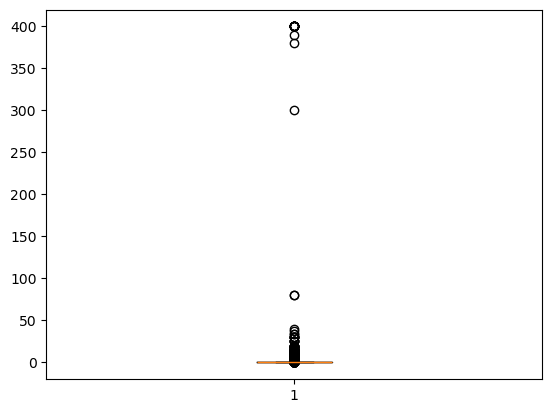

In [53]:
#Create a box plot for the price column
plt.boxplot([inp1.Price])

In [54]:
#Check the apps with price more than 200
inp1[inp1.Price > 200]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4197,most expensive app (H),FAMILY,4.3,6,1500.0,100,Paid,399.99,Everyone,Entertainment,"July 16, 2018",1.0,7.0 and up
4362,💎 I'm rich,LIFESTYLE,3.8,718,26000.0,10000,Paid,399.99,Everyone,Lifestyle,"March 11, 2018",1.0.0,4.4 and up
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7300.0,10000,Paid,400.00,Everyone,Lifestyle,"May 3, 2018",1.0.1,4.1 and up
5351,I am rich,LIFESTYLE,3.8,3547,1800.0,100000,Paid,399.99,Everyone,Lifestyle,"January 12, 2018",2.0,4.0.3 and up
5354,I am Rich Plus,FAMILY,4.0,856,8700.0,10000,Paid,399.99,Everyone,Entertainment,"May 19, 2018",3.0,4.4 and up
5355,I am rich VIP,LIFESTYLE,3.8,411,2600.0,10000,Paid,299.99,Everyone,Lifestyle,"July 21, 2018",1.1.1,4.3 and up
5356,I Am Rich Premium,FINANCE,4.1,1867,4700.0,50000,Paid,399.99,Everyone,Finance,"November 12, 2017",1.6,4.0 and up
5357,I am extremely Rich,LIFESTYLE,2.9,41,2900.0,1000,Paid,379.99,Everyone,Lifestyle,"July 1, 2018",1.0,4.0 and up
5358,I am Rich!,FINANCE,3.8,93,22000.0,1000,Paid,399.99,Everyone,Finance,"December 11, 2017",1.0,4.1 and up
5359,I am rich(premium),FINANCE,3.5,472,965.0,5000,Paid,399.99,Everyone,Finance,"May 1, 2017",3.4,4.4 and up


In [55]:
#Clean the Price column
inp1 = inp1[inp1.Price < 200] #cleaning by rewriting inp1.Price as < 200 only are included as understood from box plot
inp1.Price.describe()

count    9351.000000
mean        0.334744
std         2.169282
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        79.990000
Name: Price, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x13e52ce01d0>,
 'caps': [<matplotlib.lines.Line2D at 0x13e52ce1a50>,
 'boxes': [<matplotlib.lines.Line2D at 0x13e52cd7790>],
 'medians': [<matplotlib.lines.Line2D at 0x13e52ce3090>],
 'fliers': [<matplotlib.lines.Line2D at 0x13e52ce3bd0>],
 'means': []}

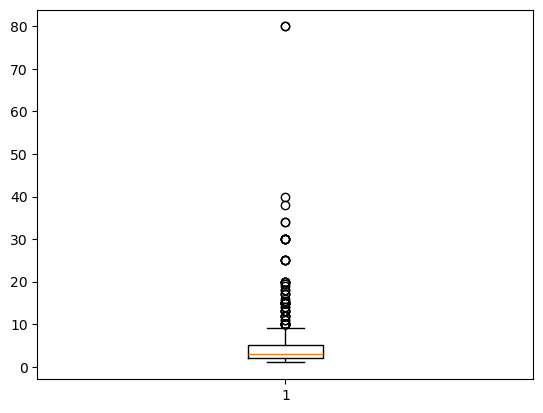

In [56]:
#Create a box plot for paid apps
plt.boxplot(inp1[inp1.Price>0].Price)

In [57]:
#Check the apps with price more than 30
inp1[inp1.Price > 30]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2253,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32000.0,1000,Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up
2301,A Manual of Acupuncture,MEDICAL,3.5,214,68000.0,1000,Paid,33.99,Everyone,Medical,"October 2, 2017",2.1.35,4.0 and up
2365,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32000.0,1000,Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up
2402,A Manual of Acupuncture,MEDICAL,3.5,214,68000.0,1000,Paid,33.99,Everyone,Medical,"October 2, 2017",2.1.35,4.0 and up
2414,LTC AS Legal,MEDICAL,4.0,6,1300.0,100,Paid,39.99,Everyone,Medical,"April 4, 2018",3.0.1,4.1 and up
5360,I am Rich Person,LIFESTYLE,4.2,134,1800.0,1000,Paid,37.99,Everyone,Lifestyle,"July 18, 2017",1.0,4.0.3 and up


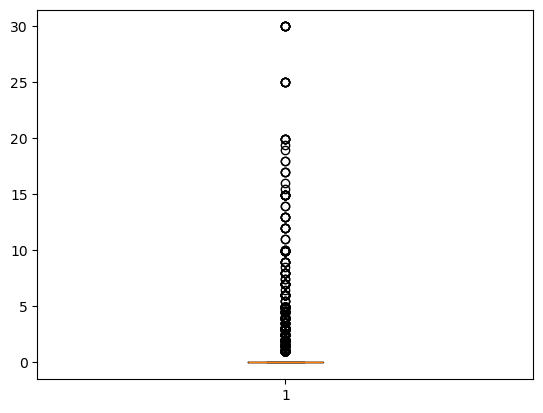

In [58]:
#Clean the Price column again
inp1 = inp1[inp1.Price <=30]
plt.boxplot(inp1.Price)
plt.show()

In [59]:
inp1.shape

(9345, 13)

(array([9.219e+03, 8.100e+01, 1.900e+01, 9.000e+00, 0.000e+00, 5.000e+00,
        0.000e+00, 3.000e+00, 7.000e+00, 2.000e+00]),
 array([1.00000000e+00, 7.81583150e+06, 1.56316620e+07, 2.34474925e+07,
        3.12633230e+07, 3.90791535e+07, 4.68949840e+07, 5.47108145e+07,
        6.25266450e+07, 7.03424755e+07, 7.81583060e+07]),
 <BarContainer object of 10 artists>)

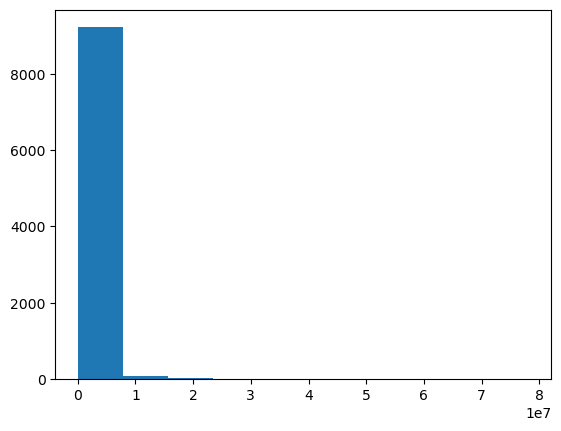

In [65]:
#Create a histogram of the Reviews
plt.hist([inp1.Reviews])

{'whiskers': [<matplotlib.lines.Line2D at 0x13e535e9090>,
 'caps': [<matplotlib.lines.Line2D at 0x13e535ea350>,
 'boxes': [<matplotlib.lines.Line2D at 0x13e535e8710>],
 'medians': [<matplotlib.lines.Line2D at 0x13e535eb490>],
 'fliers': [<matplotlib.lines.Line2D at 0x13e535ebd10>],
 'means': []}

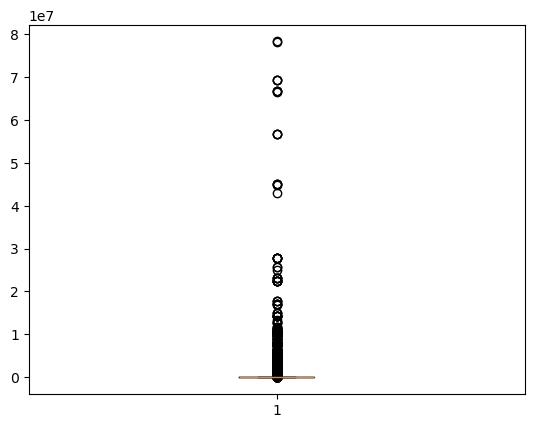

In [66]:
#Create a boxplot of the Reviews column

plt.boxplot([inp1.Reviews])

In [67]:
#Check records with 1 million reviews
inp1[inp1.Reviews > 1000000]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
139,Wattpad 📖 Free Books,BOOKS_AND_REFERENCE,4.6,2914724,21516.529524,100000000,Free,0.0,Teen,Books & Reference,"August 1, 2018",Varies with device,Varies with device
152,Google Play Books,BOOKS_AND_REFERENCE,3.9,1433233,21516.529524,1000000000,Free,0.0,Teen,Books & Reference,"August 3, 2018",Varies with device,Varies with device
189,Uber Driver,BUSINESS,4.4,1254730,21516.529524,10000000,Free,0.0,Everyone,Business,"August 3, 2018",Varies with device,Varies with device
194,OfficeSuite : Free Office + PDF Editor,BUSINESS,4.3,1002861,35000.000000,100000000,Free,0.0,Everyone,Business,"August 2, 2018",9.7.14188,4.1 and up
201,Facebook Pages Manager,BUSINESS,4.0,1279184,21516.529524,50000000,Free,0.0,Everyone,Business,"August 2, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10190,Fallout Shelter,FAMILY,4.6,2721923,25000.000000,10000000,Free,0.0,Teen,Simulation,"June 11, 2018",1.13.12,4.1 and up
10200,Facebook Pages Manager,BUSINESS,4.0,1279800,21516.529524,50000000,Free,0.0,Everyone,Business,"August 6, 2018",Varies with device,Varies with device
10327,Garena Free Fire,GAME,4.5,5534114,53000.000000,100000000,Free,0.0,Teen,Action,"August 3, 2018",1.21.0,4.0.3 and up
10636,FRONTLINE COMMANDO,GAME,4.4,1351833,12000.000000,10000000,Free,0.0,Teen,Action,"October 28, 2013",3.0.3,2.1 and up


In [68]:
#Drop the above records
inp1 = inp1[inp1.Reviews <= 1000000]
inp1.shape


(8641, 13)

(array([7175.,  521.,  314.,  169.,  127.,  114.,   69.,   49.,   55.,
          48.]),
 array([1.000000e+00, 9.950110e+04, 1.990012e+05, 2.985013e+05,
        3.980014e+05, 4.975015e+05, 5.970016e+05, 6.965017e+05,
        7.960018e+05, 8.955019e+05, 9.950020e+05]),
 <BarContainer object of 10 artists>)

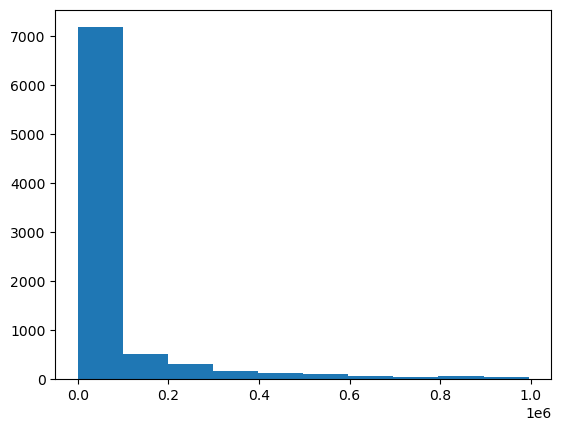

In [69]:
#Creating a histogram again and checking the peaks

plt.hist(inp1.Reviews)

count    8.641000e+03
mean     4.285064e+06
std      2.863516e+07
min      1.000000e+00
25%      1.000000e+04
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

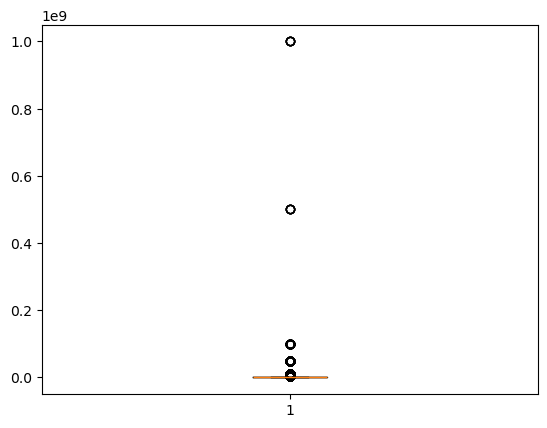

In [70]:
#Creating a box plot for the Installs column and check

plt.boxplot([inp1.Installs])
inp1.Installs.describe()

In [71]:
#CLeaning the Installs by removing all the apps having more than or equal to 100 million installs

inp1[inp1.Installs>100000000]
inp1 = inp1[inp1.Installs<100000000]
inp1.shape

(8580, 13)

(array([3218., 1351., 2192.,  562.,  422.,  269.,  177.,  126.,  106.,
         157.]),
 array([8.500000e+00, 1.000765e+04, 2.000680e+04, 3.000595e+04,
        4.000510e+04, 5.000425e+04, 6.000340e+04, 7.000255e+04,
        8.000170e+04, 9.000085e+04, 1.000000e+05]),
 <BarContainer object of 10 artists>)

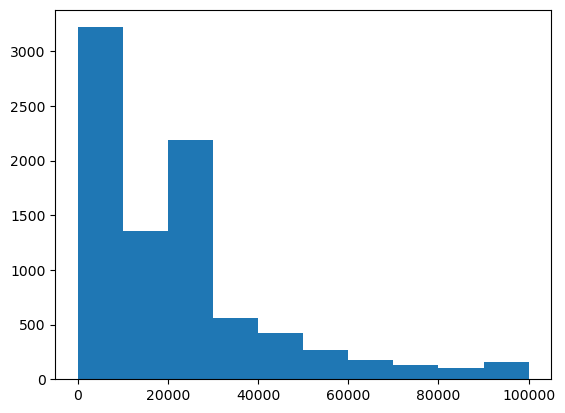

In [72]:
#Plot a histogram for Size as well.

plt.hist([inp1.Size])

count      8580.000000
mean      21620.453667
std       20705.982202
min           8.500000
25%        6000.000000
50%       18000.000000
75%       26000.000000
max      100000.000000
Name: Size, dtype: float64

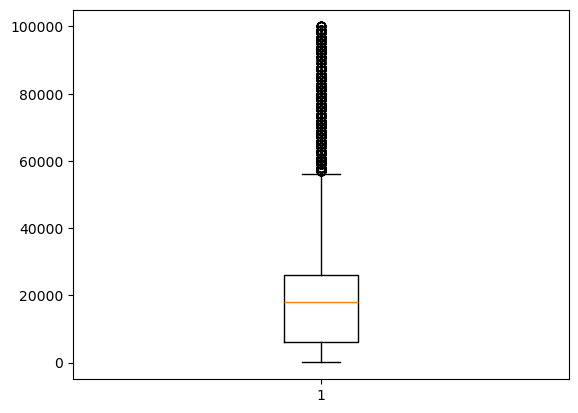

In [73]:
#Creating a boxplot for the Size column and checking

plt.boxplot([inp1.Size])
inp1.Size.describe()

### Data Visualisation with Seaborn

In [76]:
#import the necessary libraries
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

#### Distribution Plots

In [6]:
#distribution plot for ratings

sns.distplot(inp1.Rating, bins = 15, vertical=False)
plt.title('Distribution Table for Apps Rating', fontsize=15)


NameError: name 'sns' is not defined

Text(0.5, 1.0, 'Distribution Table for Apps Rating')

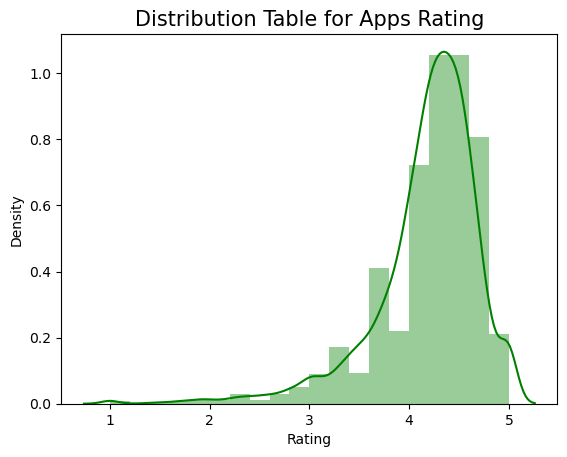

In [84]:
#Apply matplotlib functionalities
sns.distplot(inp1.Rating, bins = 20, color='green')



#### Pie-Chart and Bar Chart

In [96]:
#Analyse the Content Rating column
inp1['Content Rating'].value_counts()

Content Rating
Everyone           6904
Teen                919
Mature 17+          417
Everyone 10+        336
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

In [97]:
#Remove the rows with values which are less represented 
inp1 = inp1[~inp1['Content Rating'].isin(['Adults only 18+', 'Unrated'])]
inp1['Content Rating'].value_counts()

Content Rating
Everyone        6904
Teen             919
Mature 17+       417
Everyone 10+     336
Name: count, dtype: int64

In [98]:
#Reset the index
inp1.reset_index(inplace=True, drop=True)

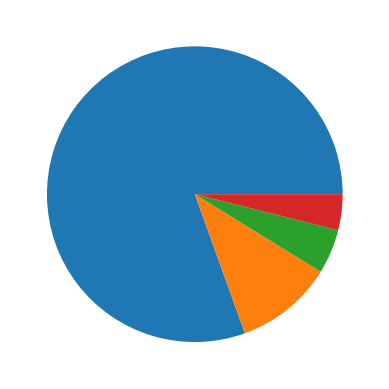

<Axes: ylabel='count'>

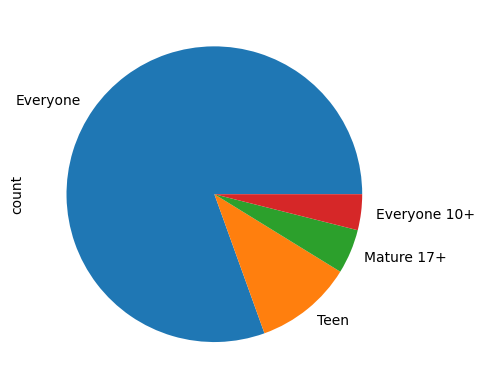

In [100]:
#Plot a pie chart
inp1['Content Rating'].value_counts().plot.pie()
plt.show()

<Axes: xlabel='Content Rating'>

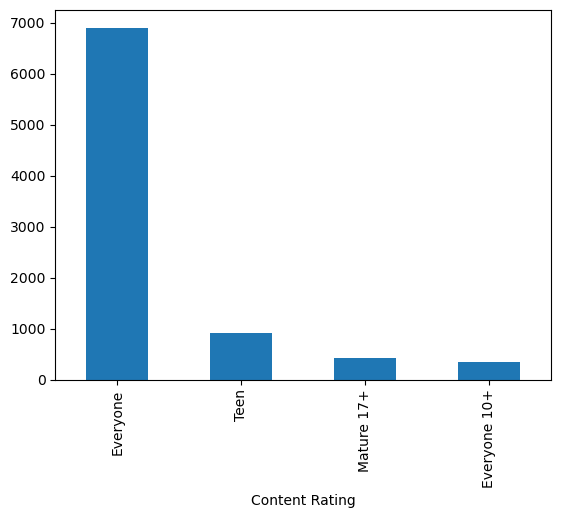

In [101]:
#Plot a bar chart
inp1['Content Rating'].value_counts().plot.bar()


In [103]:
#Question - Plot a bar plot for checking the 4th highest Android version type
inp1['Android Ver'].value_counts()

Android Ver
4.1 and up            1876
4.0.3 and up          1169
4.0 and up            1063
Varies with device     989
4.4 and up             824
2.3 and up             562
5.0 and up             527
4.2 and up             320
2.3.3 and up           232
2.2 and up             208
3.0 and up             205
4.3 and up             192
2.1 and up             110
1.6 and up              86
6.0 and up              48
7.0 and up              39
3.2 and up              31
2.0 and up              27
5.1 and up              18
1.5 and up              16
3.1 and up               7
4.4W and up              6
2.0.1 and up             6
8.0 and up               5
4.0.3 - 7.1.1            2
7.1 and up               2
5.0 - 8.0                2
1.0 and up               2
7.0 - 7.1.1              1
5.0 - 6.0                1
Name: count, dtype: int64

<Axes: xlabel='Android Ver'>

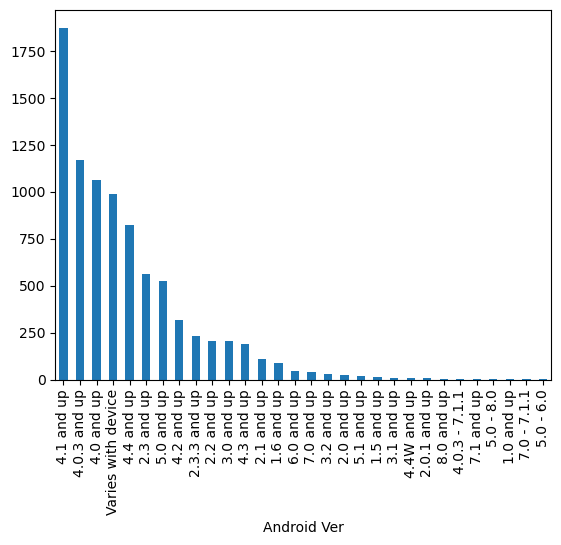

In [104]:
inp1['Android Ver'].value_counts().plot.bar()

#### Scatter Plots

Scatterplots are perhaps one of the most commonly used as well one of the most powerful visualisations you can use in the field of machine learning. They are pretty crucial in revealing relationships between the data points and you can generally deduce some sort of trends in the data with the help of a scatter plot. 

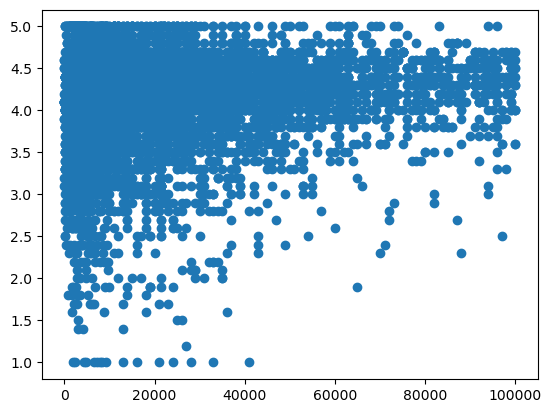

In [114]:
###Size vs Rating

##Plot a scatter-plot in the matplotlib way between Size and Rating
plt.scatter(inp1.Size, inp1.Rating)
plt.show()

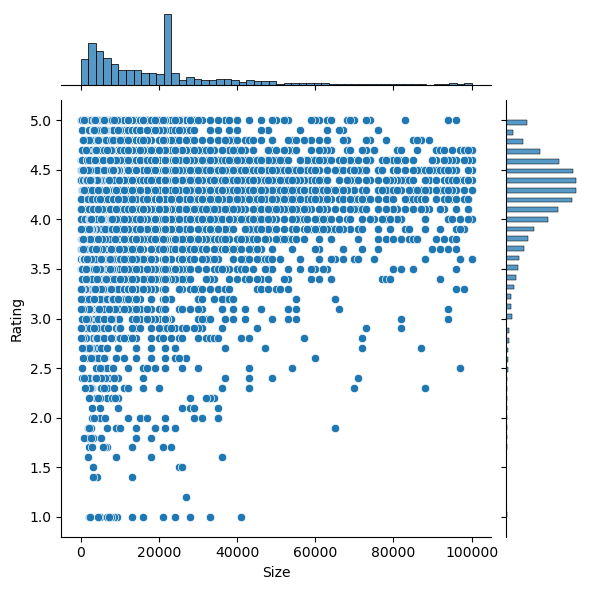

In [115]:
sns.jointplot(x='Size', y='Rating', data=inp1)    #using this form as its different with different seaborns

In [116]:
sns.set_style('white')
### Plot the same thing now using a jointplot
sns.jointplot(inp1.Size, inp1.Rating)
plt.show()

TypeError: jointplot() takes from 0 to 1 positional arguments but 2 were given

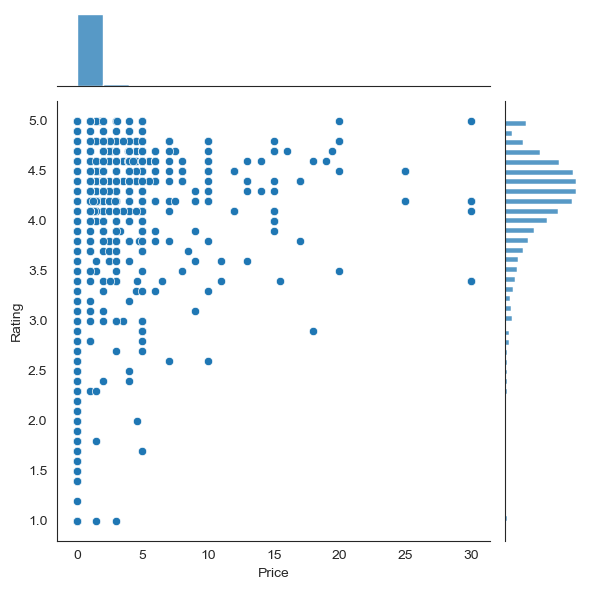

In [117]:
## Plot a jointplot for Price and Rating
sns.jointplot(x='Price', y='Rating', data=inp1)

**Reg Plots**

- These are an extension to the jointplots, where a regression line is added to the view 

![Pairplots](images\pairplots2.png)

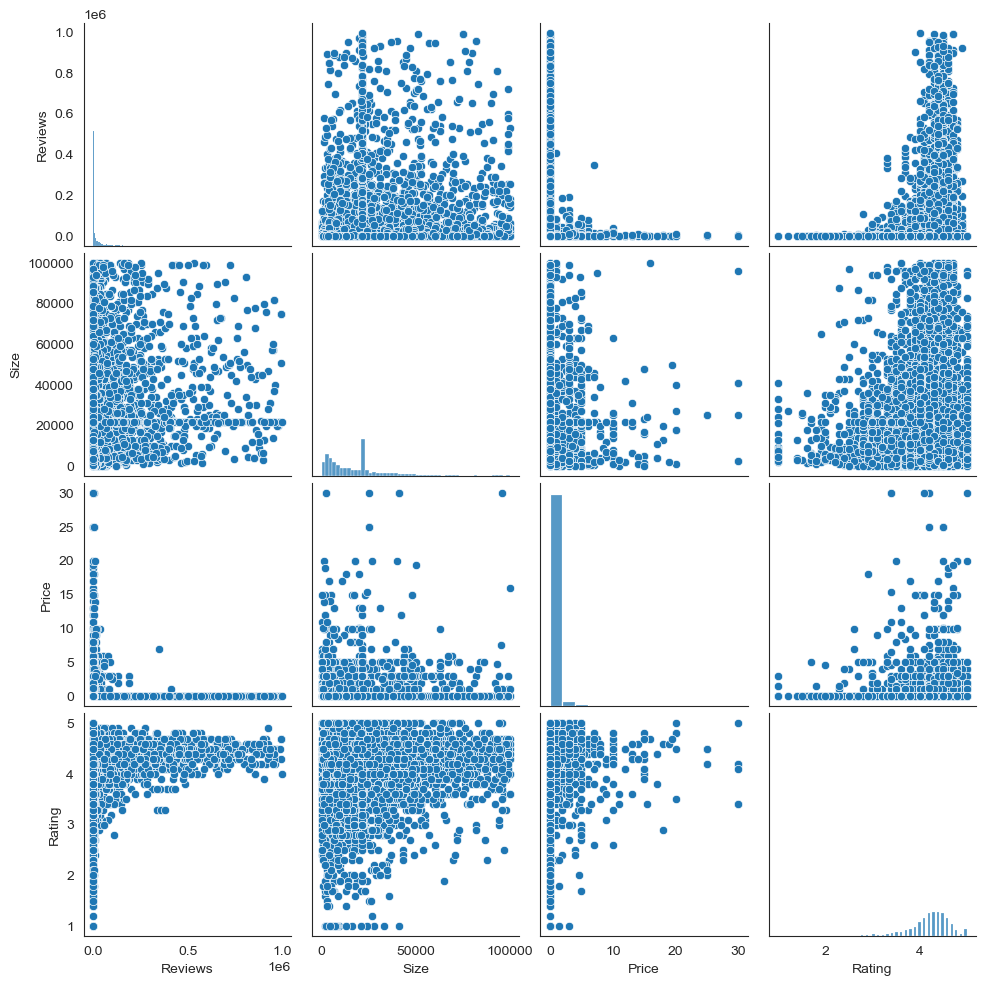

In [119]:
## Create a pair plot for Reviews, Size, Price and Rating

sns.pairplot(inp1[['Reviews', 'Size', 'Price', 'Rating']])
plt.show()

**Bar Charts Revisited**

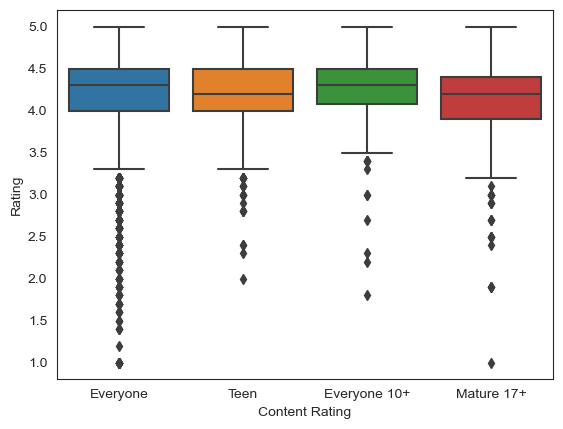

In [135]:
##Plot a box plot of Rating vs Content Rating
sns.boxplot(x='Content Rating', y='Rating', data=inp1)
plt.show()

<Axes: >

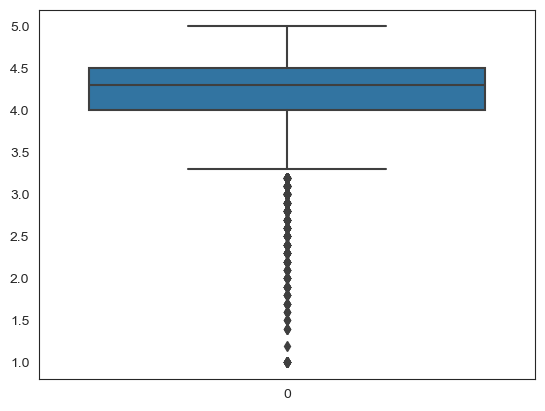

In [133]:
##Plotting a box plot for the Rating column
sns.boxplot(inp1.Rating)

<Axes: xlabel='Genres', ylabel='Rating'>

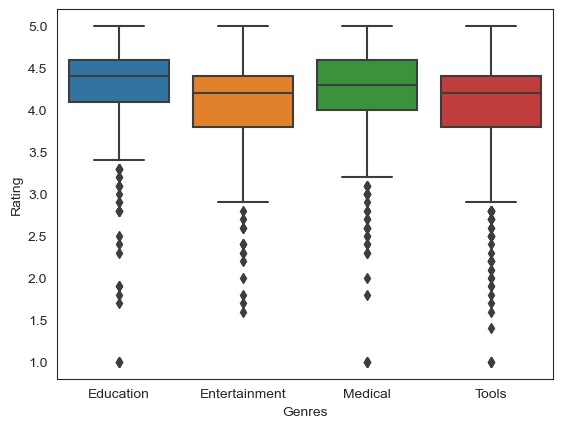

In [131]:
##Plotting a box plot of Ratings across the 4 most popular Genres
inp1.Genres.value_counts()
gens = ['Tools', 'Entertainment', 'Education', 'Medical']        
subset_gens = inp1[inp1['Genres'].isin(gens)]     

sns.boxplot(x='Genres', y='Rating', data=subset_gens)

#### Heat Maps

Heat mapsutilise the concept of using colours and colour intensities to visualise a range of values. You must have seen heat maps in cricket or football broadcasts on television to denote the players’ areas of strength and weakness.

![HeatMap](images\heatmap1.png)

- In python, you can create a heat map whenever you have a rectangular grid or table of numbers analysing any two features

![heatmap2](images\heatmap2.png)

- You'll be using **sns.heatmap()** to plot the visualisation. Checkout its official documentation :https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [169]:
##Ratings vs Size vs Content Rating

##Prepare buckets for the Size column using pd.qcut
##pd.qcut(x, q, labels)
inp1['Size_bucket']= pd.qcut(inp1.Size, 5, ['VL','L','M','H','VH'])      #in place of 5 we can also mention points [0,0.2,0.4,0.6,0.8,1]
print(inp1['Size_bucket'])

0        M
1        M
2        L
3        H
4       VL
        ..
8571    VL
8572    VH
8573    VL
8574     M
8575     M
Name: Size_bucket, Length: 8576, dtype: category
Categories (5, object): ['VL' < 'L' < 'M' < 'H' < 'VH']


In [151]:
##Creating a pivot table for Size_buckets and Content Rating with values set to Rating        
pd.pivot_table(data=inp1, index='Content Rating', columns='Size_bucket', values='Rating')        #default -> mean value grid & see format - pivot_table

Size_bucket,VL,L,M,H,VH
Content Rating,,,,,
Everyone,4.116677,4.158839,4.217012,4.172138,4.187102
Everyone 10+,4.188889,4.207143,4.238318,4.193443,4.216393
Mature 17+,3.951429,4.129592,4.021705,4.155172,4.193814
Teen,4.228421,4.208511,4.141637,4.198131,4.246102


In [171]:
##Changing
the aggregation to median
mean= pd.pivot_table(data=inp1, index='Content Rating', columns='Size_bucket', values='Rating', aggfunc=np.median)

In [177]:
##Change the aggregation to 20th percentile
med = pd.pivot_table(data=inp1, index='Content Rating', columns='Size_bucket', values='Rating', aggfunc=lambda x: np.quantile(x,0.2))

In [157]:
##Store the pivot table in a separate variable
res = pd.pivot_table(data=inp1, index='Content Rating', columns='Size_bucket', values='Rating', aggfunc=lambda x: np.quantile(x,0.2))

<Axes: xlabel='Size_bucket', ylabel='Content Rating'>

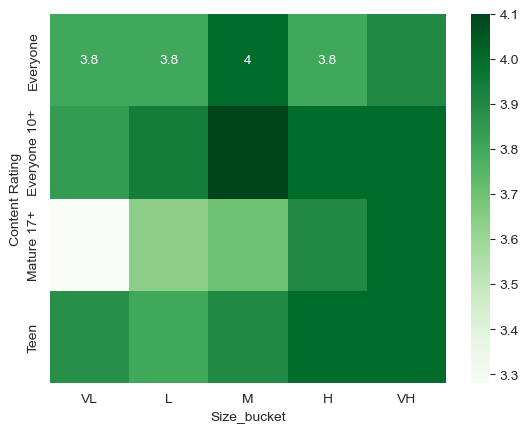

In [181]:
##creating heatmap
sns.heatmap(res, cmap='Greens', annot=True)

In [191]:
## Replace Content Rating with Review_buckets in the above heat map
##Keep the aggregation at minimum value for Rating
inp1.Reviews.value_counts()         #since this is a numerical value -> converting it to categorial column
#using qcut
inp1['Reviews_bucket']= pd.qcut(inp1.Reviews, [0,0.25,0.50,0.75,1], ['Low','Medium','High','Very_High'])
inp1.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_bucket,Reviews_bucket
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M,Medium
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M,Medium
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,L,Very_High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,H,Very_High
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,VL,Medium


In [193]:
#Reviews_bucket created now use pivot table for min func
pd.pivot_table(data=inp1, index='Reviews_bucket', columns='Size_bucket', values='Rating', aggfunc=np.min)

Size_bucket,VL,L,M,H,VH
Reviews_bucket,,,,,
Low,1.0,1.0,1.0,1.0,1.0
Medium,1.6,1.7,1.9,2.1,1.6
High,2.4,2.9,2.5,2.9,2.7
Very_High,3.3,3.4,3.0,2.8,3.3


In [195]:
ques = pd.pivot_table(data=inp1, index='Reviews_bucket', columns='Size_bucket', values='Rating', aggfunc=np.min)

<Axes: xlabel='Size_bucket', ylabel='Reviews_bucket'>

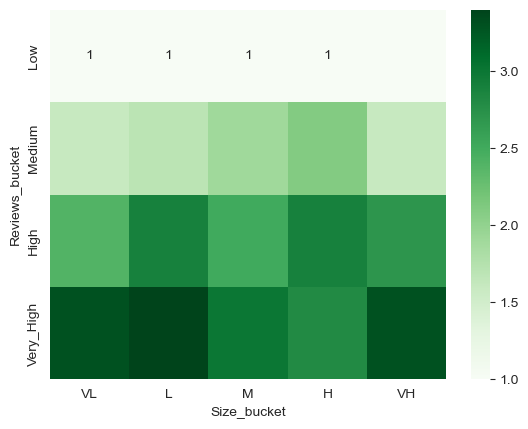

In [199]:
sns.heatmap(ques, cmap='Greens', annot=True)

### Session 3: Additional Visualisations

#### Line Plots

In [213]:
## Extract the month from the Last Updated Date
inp1.dtypes
inp1['Last Updated'].head()
#to extract

inp1['Updated Month'] = pd.to_datetime(inp1['Last Updated']).dt.month

In [215]:
## Find the average Rating across all the months

inp1.groupby(['Updated Month'])['Rating'].mean()

Updated Month
1     4.145050
2     4.092566
3     4.111255
4     4.148326
5     4.153894
6     4.172865
7     4.223268
8     4.271197
9     4.041406
10    4.012739
11    4.102020
12    4.064939
Name: Rating, dtype: float64

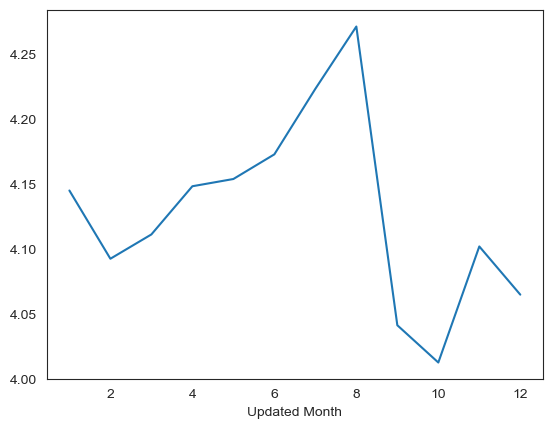

In [217]:
## Plot a line graph

inp1.groupby(['Updated Month'])['Rating'].mean().plot()
plt.show()

#### Stacked Bar Charts

In [224]:
## Create a pivot table for Content Rating and updated Month with the values set to Installs
pd.pivot_table(data=inp1, index='Updated Month', columns='Content Rating', values='Installs', aggfunc=sum)

Content Rating,Everyone,Everyone 10+,Mature 17+,Teen
Updated Month,,,,
1,725387390,105282000,9701210,44159010
2,545372006,19821000,13021500,39597710
3,695365531,30322510,9111100,79850310
4,973371180,23300000,5259000,161619410
5,1461067800,118173500,50140100,202689600
6,2127170505,217727100,145257200,415716600
7,6371119685,456556000,419491910,1143556810
8,4430943321,215821000,312981700,1057855650
9,260340410,24931100,2201010,22483100


In [232]:
##Store the table in a separate variable
monthly = pd.pivot_table(data=inp1, index='Updated Month', columns='Content Rating', values='Installs', aggfunc=sum)

<Axes: xlabel='Updated Month'>

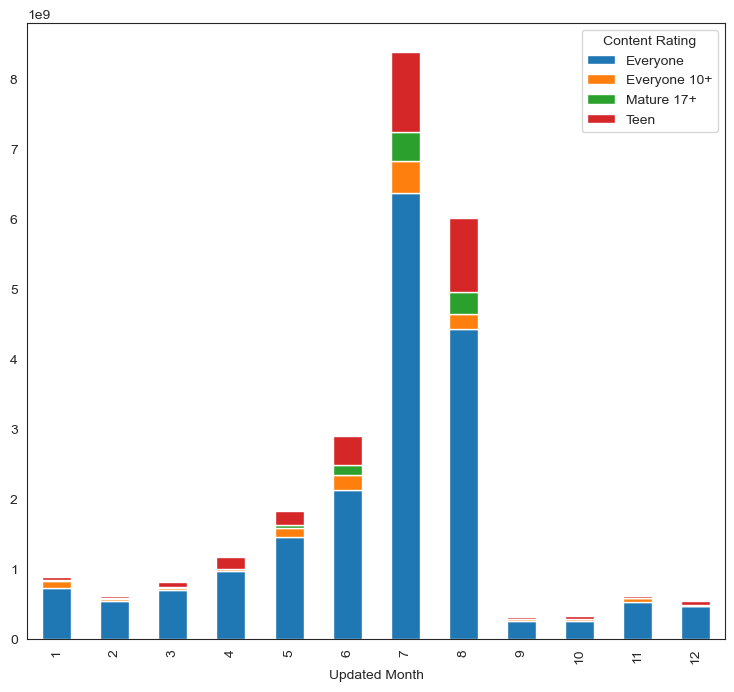

In [234]:
##Plot the stacked bar chart.
monthly.plot(kind='bar', stacked='True', figsize=[9,8])

<Axes: xlabel='Updated Month'>

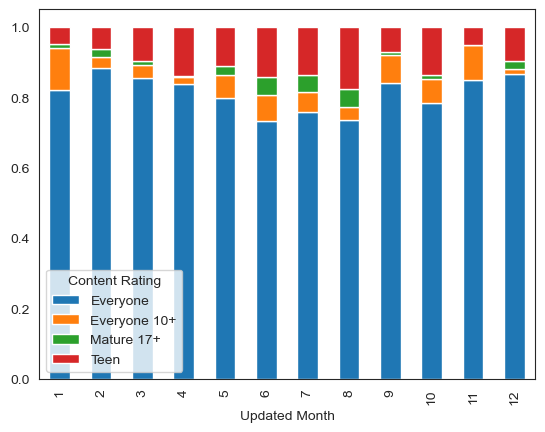

In [242]:
##Plot the stacked bar chart again wrt to the proportions.
#for proportion = x/x(total)

month_perc = monthly[['Everyone','Everyone 10+','Mature 17+','Teen']].apply(lambda x: x/x.sum(), axis=1)
month_perc.plot(kind='bar', stacked='True')

We can see month 6,7,8 have high teen installing apps due to holiday break